### REVISION POINTS
- Local features detection by CNN.(Not global like transformer)
- Effects of translation and rotation when using CNN. Translation invariance but not rotation invariance
- Initial layers being transferable

In [1]:
# Importing the libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


## POINTS TO LOOK INTO
- What are the principles of train,test,val splits.
- Best practices or the general practices regarding the slpits

### Data preperation and Data loaders setup

In [2]:
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Define the transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the full MNIST dataset
full_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)


In [3]:
# Extract data and labels
data = full_data.data  # Tensor of shape [60000, 28, 28]
labels = full_data.targets  # Tensor of shape [60000]


In [4]:
from sklearn.model_selection import train_test_split

# Stratified train-test split (80% train, 20% test)
train_idx, test_idx = train_test_split(
    range(len(data)),               # Indices for the dataset
    test_size=0.2,                  # 20% for test
    stratify=labels,                # Maintain class distribution
    random_state=42                 # For reproducibility
)

# Create Subset datasets
train_data = Subset(full_data, train_idx)
test_data = Subset(full_data, test_idx)


In [5]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [6]:
# shape of one sample image
sample_image, sample_label = train_data[0]  
print(f"Image Shape: {sample_image.shape}")
print(f"Label: {sample_label}")

Image Shape: torch.Size([1, 28, 28])
Label: 1


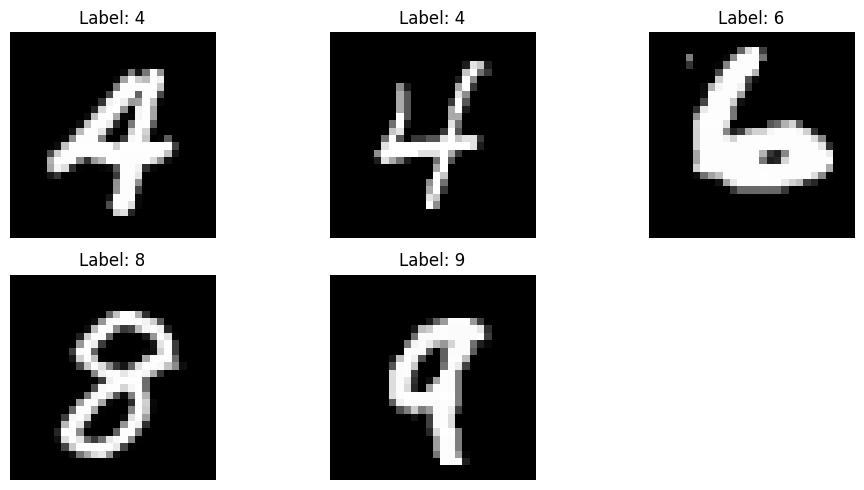

In [7]:
plt.figure(figsize=(10, 5))
    
# Randomly select samples from the dataset
indices = np.random.choice(len(train_data), 5, replace=False)

for i, idx in enumerate(indices):
    image, label = train_data[idx]

    # Display the image
    plt.subplot(2, 3, i + 1)
    plt.imshow(image.squeeze(), cmap='gray')  # `.squeeze()` removes extra dimensions
    plt.title(f'Label: {label}')
    plt.axis('off')

plt.tight_layout()
plt.show()


## Revision type points
- Convolution layers contibuting to more training time.
- FCC layer contribution to more number of parameters

## POINTS TO LOOK INTO
- How padding, stride and kernel size effects the output size.
- How to calculate the in_features for the first full connected layer

In [8]:
# the input image is of shape : (28 x 28 x 1)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # Input: 1 channel (grayscale), 32 filter.  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 64 filters      
        self.pool = nn.MaxPool2d(2, 2)  # Downsamples by 2x                
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Fully connected layer 
        self.fc2 = nn.Linear(128, 10)          # 10 classes for digits 0-9

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Convolution -> ReLU -> Pooling     final size : 14 x 14 x 32
        x = self.pool(F.relu(self.conv2(x)))                                     # final size : 7 x 7 x 64
        x = x.view(-1, 64 * 7 * 7)            # Flatten the feature maps
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    

## POINTS TO LOOK INTO
- How loss.backward() or backpropagation is done for the kernel weights in convolution layers.
- What is deconvolution and where is it needed and how to do it.

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()  # Suitable for classification tasks
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
def train(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()          # Clear previous gradients
            outputs = model(images)        # Forward pass
            loss = criterion(outputs, labels)
            loss.backward()                # Backpropagation
            optimizer.step()               # Update weights
            
            total_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")




In [10]:
for name, layer in model.named_children():
    print(f"{name}: {layer}")

conv1: Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
conv2: Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
pool: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
fc1: Linear(in_features=3136, out_features=128, bias=True)
fc2: Linear(in_features=128, out_features=10, bias=True)


In [11]:
train(model, train_loader, criterion, optimizer)

Epoch [1/5], Loss: 0.1847
Epoch [2/5], Loss: 0.0501
Epoch [3/5], Loss: 0.0340
Epoch [4/5], Loss: 0.0247
Epoch [5/5], Loss: 0.0200


In [12]:
def test(model, test_loader):
    model.eval()  # Evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():  # No gradient calculation needed
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f'Accuracy on test data: {100 * correct / total:.2f}%')

test(model, test_loader)


Accuracy on test data: 98.79%


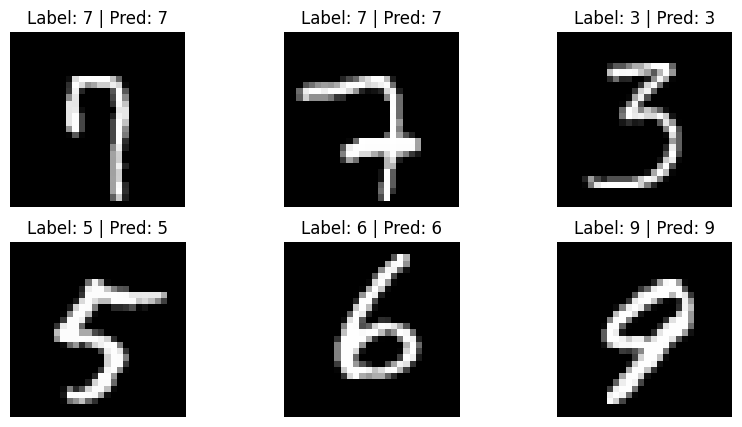

In [13]:
import matplotlib.pyplot as plt

# Display sample predictions
def visualize_predictions(model, test_loader):
    model.eval()
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    
    with torch.no_grad():
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs, 1)

    # Display 6 sample images
    plt.figure(figsize=(10, 5))
    for idx in range(6):
        plt.subplot(2, 3, idx + 1)
        plt.imshow(images[idx].squeeze(), cmap='gray')
        plt.title(f'Label: {labels[idx]} | Pred: {predicted[idx].item()}')
        plt.axis('off')
    plt.show()

visualize_predictions(model, test_loader)
